In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Rastgele veri üretimi
np.random.seed(42)
n = 100
tv = np.random.normal(200, 50, n)
radyo = np.random.normal(40, 10, n)
gazete = np.random.normal(20, 5, n)
satis = (tv * 0.5) + (radyo * 1.2) + (gazete * 0.1) + np.random.normal(0, 5, n)


In [3]:
df = pd.DataFrame({'TV': tv, 'Radyo': radyo, 'Gazete': gazete, 'Satis': satis})
print(df.head())

           TV      Radyo     Gazete       Satis
0  224.835708  25.846293  21.788937  141.467324
1  193.086785  35.793547  22.803923  138.975136
2  232.384427  36.572855  25.415256  166.357633
3  276.151493  31.977227  25.269010  182.027172
4  188.292331  38.387143  13.111653  141.417394


In [4]:
#train test split
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

X_train, X_test , y_train , y_test= train_test_split(X,y,test_size=0.2,random_state=15)


In [5]:
#standatization
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [6]:
#Linarregression
model = LinearRegression()
model.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_pred=model.predict(X_test)
print(y_pred)


[128.98863062 144.79946608 147.89225307 145.42435996 123.93953211
 149.28682673 127.80635633 105.6819363  139.13443387 182.18614731
 154.994306   127.14478065 132.79551974 147.0949209  142.086218
 179.58220921 110.67949342 164.62697654 142.87777432 158.52924563]


In [8]:
#metrices
mae = mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
print("mae:",mae)
print("mse:",mse)
print("r2:",r2)
print("rmse:",rmse)

mae: 4.853819859173724
mse: 30.606687457619206
r2: 0.9158634924933091
rmse: 5.532331105205039


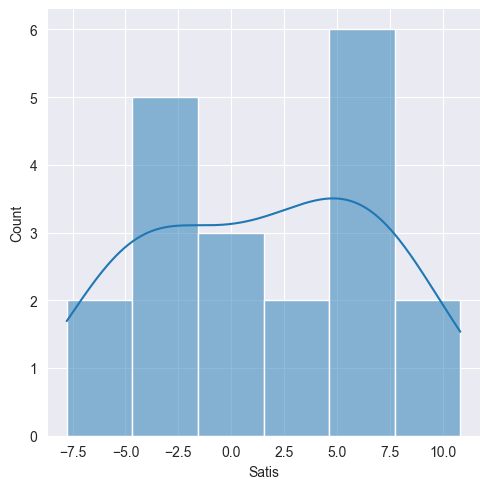

In [9]:
#plot graph
residul = y_test - y_pred
sns.displot(residul,kde=True)
plt.show()


In [10]:
print(model.coef_)


[23.27554851 11.73012908  0.56075581]


In [11]:
#test data
newdata=[[220,25,21]]


In [12]:
predict_score= model.predict(scaler.transform(newdata))
print("Predict: ", predict_score)

Predict:  [142.14203412]


C:\Users\Monster\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
